In [1]:
import pandas as pd
import numpy as np
from huggingface_hub import HfFileSystem

HF_REPO = "vngclinh/goodreads-preprocessed"
hf_fs = HfFileSystem()

def hf_read(path):
    with hf_fs.open(f"datasets/{HF_REPO}/{path}", "rb") as f:
        return pd.read_parquet(f)

book_vecs   = hf_read("lda/book_topic_vectors.parquet")   # (447813, 41)
topic_terms = hf_read("lda/topic_terms.parquet")           # (40, 2)

topic_cols = [f"t{i}" for i in range(40)]
print(book_vecs.shape, topic_terms.head())

(447813, 41)    topic_id                                          top_terms
0         0  [island, animal, dog, lucy, human, people, shi...
1         1  [war, history, american, country, people, time...
2         2  [que, una, los, con, libro, por, pero, ma, com...
3         3  [movie, music, film, star, time, year, voice, ...
4         4  [world, like, cinder, zombie, horror, tale, dy...


In [2]:
genres = [
    "children", "comics_-graphic", "fantasy_-paranormal", "fiction",
    "history_-historical-fiction_-biography", "mystery_-thriller_-crime",
    "non-fiction", "poetry", "romance", "young-adult"
]

book_genre_parts = []
for g in genres:
    df = hf_read(f"data/{g}.parquet")[["book_id", "primary_genre"]].drop_duplicates("book_id")
    book_genre_parts.append(df)

book_genre = pd.concat(book_genre_parts).drop_duplicates("book_id")
print(f"Unique books with genre: {len(book_genre)}")

Unique books with genre: 1765583


In [4]:
merged = book_vecs.merge(book_genre, on="book_id")

# Mean topic vector per genre → shape (10, 40)
genre_fp = merged.groupby("primary_genre")[topic_cols].mean()

# Normalize rows (probability dist)
genre_fp_norm = genre_fp.div(genre_fp.sum(axis=1), axis=0)

genre_fp.to_parquet("/kaggle/working/lda/genre_fingerprint.parquet")
print(genre_fp_norm.round(3))

                                           t0     t1     t2     t3     t4  \
primary_genre                                                               
children                                0.036  0.016  0.017  0.022  0.032   
comics, graphic                         0.013  0.022  0.038  0.013  0.116   
fantasy, paranormal                     0.014  0.009  0.025  0.010  0.058   
fiction                                 0.018  0.039  0.030  0.015  0.030   
history, historical fiction, biography  0.016  0.151  0.013  0.018  0.008   
mystery, thriller, crime                0.016  0.027  0.016  0.015  0.017   
non-fiction                             0.022  0.055  0.013  0.015  0.009   
poetry                                  0.013  0.021  0.020  0.011  0.009   
romance                                 0.011  0.008  0.020  0.010  0.009   
young-adult                             0.013  0.010  0.037  0.013  0.028   

                                           t5     t6     t7     t8     t9  

In [5]:
# Variance across genres per topic = how genre-specific that topic is
between_var = genre_fp.var(axis=0)                              # (40,)
within_var  = merged.groupby("primary_genre")[topic_cols].var().mean()  # (40,)
disc = (between_var / (within_var + 1e-9)).rename("discrimination")

top10 = disc.nlargest(10)
print("Most discriminative topics:")
for tid_str, score in top10.items():
    tid = int(tid_str[1:])
    terms = topic_terms.loc[topic_terms.topic_id == tid, "top_terms"].values[0]
    print(f"  {tid_str} ({score:.2f}): {terms}")

Most discriminative topics:
  t32 (0.52): ['mystery' 'character' 'murder' 'series' 'novel' 'plot' 'crime' 'case'
 'killer' 'thriller']
  t19 (0.48): ['love' 'romance' 'loved' 'series' 'hot' 'sex' 'relationship' 'get' 'two'
 'sweet']
  t36 (0.33): ['like' 'novel' 'time' 'poem' 'man' 'word' 'poetry' 'life' 'first' 'world']
  t20 (0.29): ['art' 'amy' 'christmas' 'cat' 'oliver' 'child' 'picture' 'love' 'artist'
 'eve']
  t27 (0.28): ['author' 'work' 'time' 'reader' 'reading' 'would' 'many' 'writing' 'also'
 'well']
  t1 (0.27): ['war' 'history' 'american' 'country' 'people' 'time' 'america' 'world'
 'year' 'state']
  t4 (0.24): ['world' 'like' 'cinder' 'zombie' 'horror' 'tale' 'dystopian' 'sci'
 'alien' 'human']
  t17 (0.12): ['world' 'series' 'king' 'find' 'prince' 'queen' 'character' 'love'
 'romance' 'also']
  t28 (0.09): ['really' 'like' 'character' 'much' 'would' 'liked' 'thing' 'think' 'good'
 'felt']
  t26 (0.09): ['year' 'family' 'friend' 'girl' 'school' 'life' 'mother' 'father'
 '

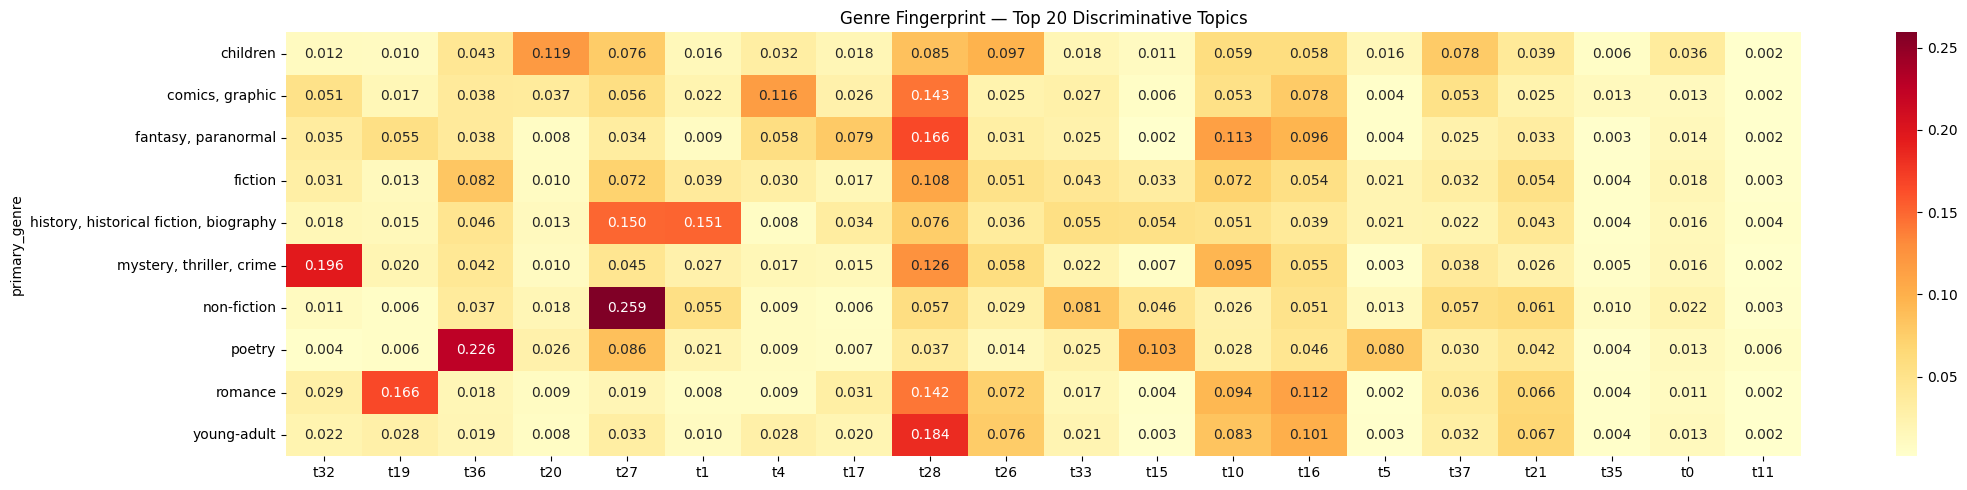

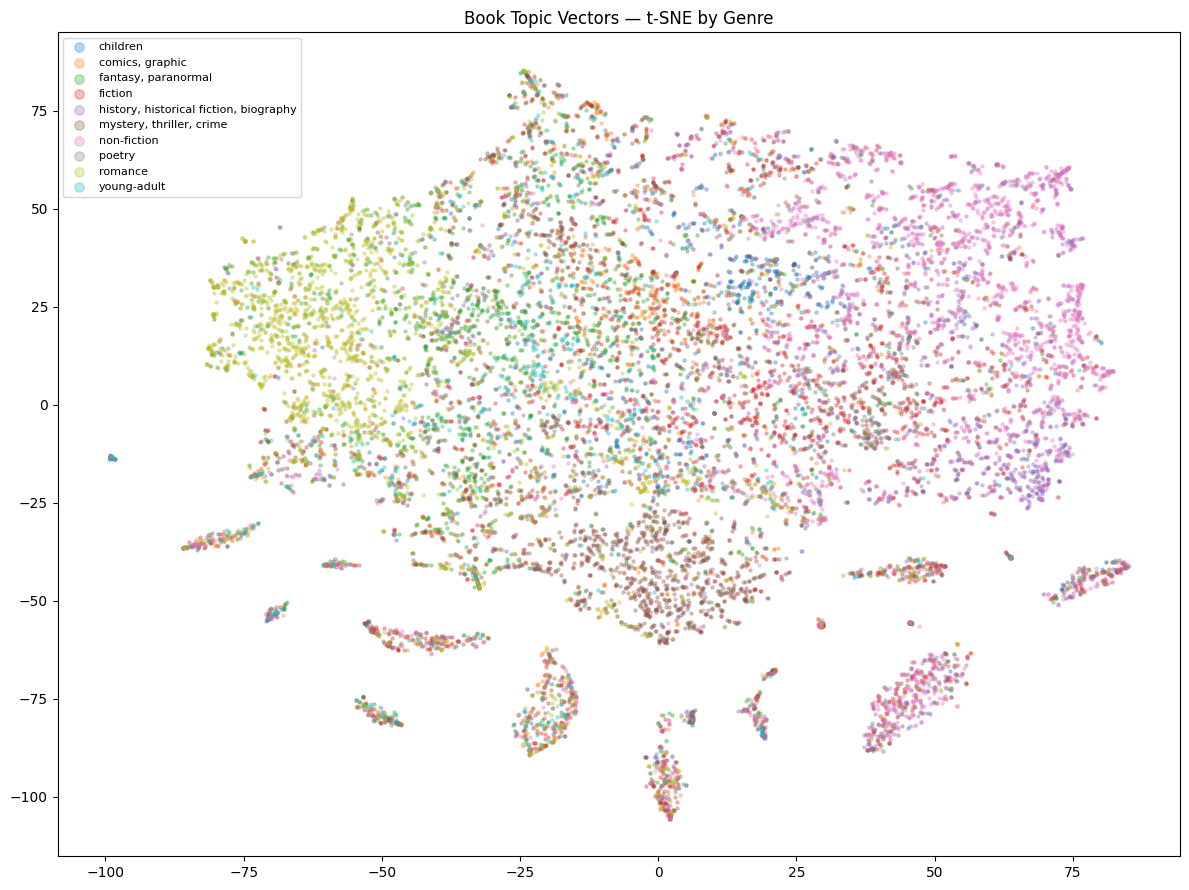

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# 5a. Heatmap genre × top-discriminative topics
top20_topics = disc.nlargest(20).index.tolist()
fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(genre_fp_norm[top20_topics], annot=True, fmt=".3f",
            cmap="YlOrRd", ax=ax)
ax.set_title("Genre Fingerprint — Top 20 Discriminative Topics")
plt.tight_layout()
plt.savefig("/kaggle/working/lda/genre_heatmap.png", dpi=150)

# 5b. t-SNE books colored by genre (sample 15k)
sample = merged.sample(15_000, random_state=42)
coords = TSNE(n_components=2, random_state=42, n_jobs=-1
              ).fit_transform(sample[topic_cols].values)
fig, ax = plt.subplots(figsize=(12, 9))
for g, grp in sample.assign(x=coords[:,0], y=coords[:,1]).groupby("primary_genre"):
    ax.scatter(grp.x, grp.y, label=g, alpha=0.3, s=5)
ax.legend(markerscale=3, fontsize=8)
ax.set_title("Book Topic Vectors — t-SNE by Genre")
plt.tight_layout()
plt.savefig("/kaggle/working/lda/tsne_genres.png", dpi=150)

In [8]:
import time
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
HF_REPO = "vngclinh/goodreads-preprocessed"
api = HfApi()

files = ["genre_fingerprint.parquet", "genre_heatmap.png", "tsne_genres.png"]

for fname in files:
    for attempt in range(3):
        try:
            api.upload_file(
                path_or_fileobj=f"/kaggle/working/lda/{fname}",
                path_in_repo=f"lda/{fname}",
                repo_id=HF_REPO, repo_type="dataset", token=HF_TOKEN
            )
            print(f"✓ {fname}")
            break
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
            time.sleep(5)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✓ genre_fingerprint.parquet


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✓ genre_heatmap.png


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✓ tsne_genres.png
